# K-Means: Random Initialization Trap & K-Means++ (Deep Dive)


This notebook is dedicated entirely to **proving, visually and numerically, why the random
initialization trap is real** and **why K-Means++ fixes it** — something the other K-Means notebooks
only mention briefly.

We will:
1. Manually force a "bad" random initialization and watch K-Means converge to a wrong-looking result
2. Compare `init='random'` vs `init='k-means++'` on the exact same data
3. Run **many trials** and measure how often plain random init gets stuck in a bad local optimum vs K-Means++
4. Show why `n_init` (running K-Means multiple times and keeping the best) is extra insurance on top of K-Means++

## 1. Setup: Create Data Where Bad Initialization Can Actually Happen

We need 3 natural groups where two of them sit relatively close together — this is exactly the setup described in the notes where 2 random centroids can accidentally land in/near the same group.

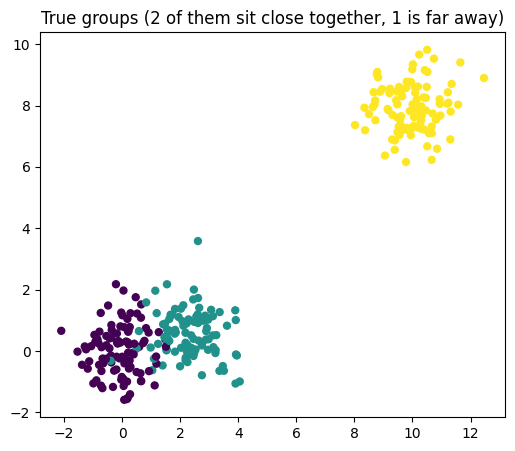

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# 3 clusters: two of them (0 and 1) are closer to each other than to cluster 2,
# which makes bad random initialization more likely to happen.
centers = [[0, 0], [2.2, 0.5], [10, 8]]
X, true_labels = make_blobs(n_samples=300, centers=centers, cluster_std=0.8, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', s=25)
plt.title("True groups (2 of them sit close together, 1 is far away)")
plt.show()

## 2. Force a Bad Initialization (Using a Known Unlucky Random Seed)

Rather than hand-picking centroids (which Lloyd's algorithm can sometimes self-correct away from), we'll do something more honest: scan through plain `init='random'` runs and find a real seed where K-Means genuinely lands in a bad local optimum — exactly the kind of bad luck described in the notes.

Worst seed found: 44, WCSS = 620.45
Resulting cluster sizes: [61, 200, 39]  (data was generated with ~100 points per true group)


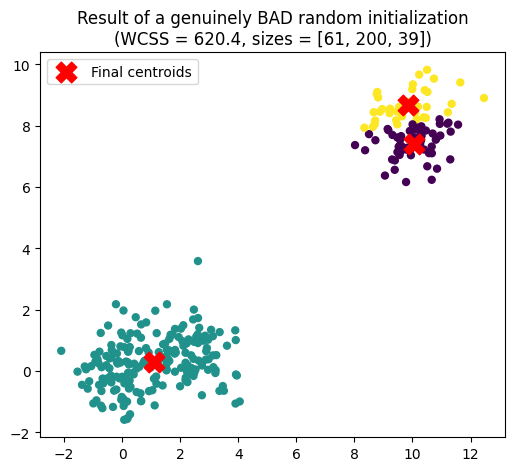

In [2]:
def euclidean(a, b):
    return np.sqrt(((a - b) ** 2).sum(axis=-1))

# Scan seeds 0-199 using PLAIN random init (no k-means++, no retries) and keep the worst one
worst_seed, worst_wcss = None, -1
for seed in range(200):
    km_trial = KMeans(n_clusters=3, init='random', n_init=1, random_state=seed)
    km_trial.fit(X)
    if km_trial.inertia_ > worst_wcss:
        worst_seed, worst_wcss = seed, km_trial.inertia_

print(f"Worst seed found: {worst_seed}, WCSS = {worst_wcss:.2f}")

# Refit with that exact seed to get the bad result to visualize
km_bad = KMeans(n_clusters=3, init='random', n_init=1, random_state=worst_seed)
bad_labels = km_bad.fit_predict(X)
bad_centroids = km_bad.cluster_centers_
bad_wcss = km_bad.inertia_

cluster_sizes = [int((bad_labels == i).sum()) for i in range(3)]
print(f"Resulting cluster sizes: {cluster_sizes}  (data was generated with ~100 points per true group)")

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=bad_labels, cmap='viridis', s=25)
plt.scatter(bad_centroids[:, 0], bad_centroids[:, 1], c='red', marker='X', s=220,
            label='Final centroids', zorder=5)
plt.title(f"Result of a genuinely BAD random initialization\n(WCSS = {bad_wcss:.1f}, sizes = {cluster_sizes})")
plt.legend()
plt.show()

**Observation:** Notice the cluster sizes are **badly uneven** (compare to the ~100/100/100 split the data was actually generated with). Plain random initialization got unlucky on this seed and converged to a **worse local optimum** — the algorithm still ran correctly (assign → update → converge), but it settled on a visibly wrong grouping. This is the **random initialization trap** exactly as described in the theory notes.

## 3. Now Compare with K-Means++ on the Exact Same Data

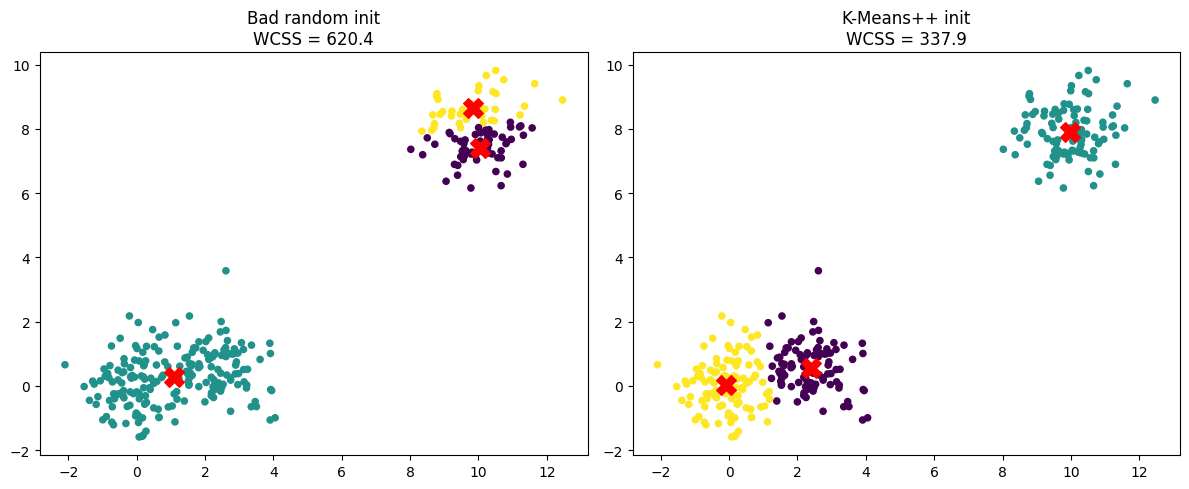

Bad init WCSS:      620.45
K-Means++ WCSS:     337.88
K-Means++ is 1.84x better (lower WCSS) on this run.


In [3]:
kmeans_pp = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
pp_labels = kmeans_pp.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=bad_labels, cmap='viridis', s=20)
axes[0].scatter(bad_centroids[:, 0], bad_centroids[:, 1], c='red', marker='X', s=200)
axes[0].set_title(f"Bad random init\nWCSS = {bad_wcss:.1f}")

axes[1].scatter(X[:, 0], X[:, 1], c=pp_labels, cmap='viridis', s=20)
axes[1].scatter(kmeans_pp.cluster_centers_[:, 0], kmeans_pp.cluster_centers_[:, 1],
                c='red', marker='X', s=200)
axes[1].set_title(f"K-Means++ init\nWCSS = {kmeans_pp.inertia_:.1f}")

plt.tight_layout()
plt.show()

print(f"Bad init WCSS:      {bad_wcss:.2f}")
print(f"K-Means++ WCSS:     {kmeans_pp.inertia_:.2f}")
print(f"K-Means++ is {(bad_wcss / kmeans_pp.inertia_):.2f}x better (lower WCSS) on this run.")

**Observation:** Lower WCSS = tighter, more accurate clusters. K-Means++ starts by spreading centroids apart, so it correctly finds the 3 real groups instead of splitting one group in two while merging others.

## 4. The Real Proof: Run Many Trials and Measure How Often Things Go Wrong

A single example can be cherry-picked. Let's be rigorous: run K-Means **100 times** with plain random
initialization (`init='random'`, `n_init=1` — no retries) vs **100 times** with K-Means++
(`init='k-means++'`, `n_init=1` — also no retries, for a fair comparison), and look at the
**distribution of final WCSS** each method lands on.

In [4]:
n_trials = 100
random_wcss = []
pp_wcss = []

for seed in range(n_trials):
    km_random = KMeans(n_clusters=3, init='random', n_init=1, random_state=seed)
    km_random.fit(X)
    random_wcss.append(km_random.inertia_)

    km_pp = KMeans(n_clusters=3, init='k-means++', n_init=1, random_state=seed)
    km_pp.fit(X)
    pp_wcss.append(km_pp.inertia_)

random_wcss = np.array(random_wcss)
pp_wcss = np.array(pp_wcss)

print(f"Plain random init  -> mean WCSS: {random_wcss.mean():.1f}, worst WCSS: {random_wcss.max():.1f}, std: {random_wcss.std():.1f}")
print(f"K-Means++ init     -> mean WCSS: {pp_wcss.mean():.1f}, worst WCSS: {pp_wcss.max():.1f}, std: {pp_wcss.std():.1f}")

# "Bad outcome" = WCSS noticeably higher than the best possible result found across all trials
best_possible = min(random_wcss.min(), pp_wcss.min())
bad_outcome_threshold = best_possible * 1.5

pct_random_bad = (random_wcss > bad_outcome_threshold).mean() * 100
pct_pp_bad = (pp_wcss > bad_outcome_threshold).mean() * 100

print(f"\n% of trials landing on a clearly BAD result (WCSS > 1.5x best found):")
print(f"  Plain random init : {pct_random_bad:.1f}% of {n_trials} trials")
print(f"  K-Means++         : {pct_pp_bad:.1f}% of {n_trials} trials")

Plain random init  -> mean WCSS: 407.4, worst WCSS: 620.4, std: 120.5
K-Means++ init     -> mean WCSS: 354.6, worst WCSS: 619.7, std: 66.1

% of trials landing on a clearly BAD result (WCSS > 1.5x best found):
  Plain random init : 25.0% of 100 trials
  K-Means++         : 6.0% of 100 trials


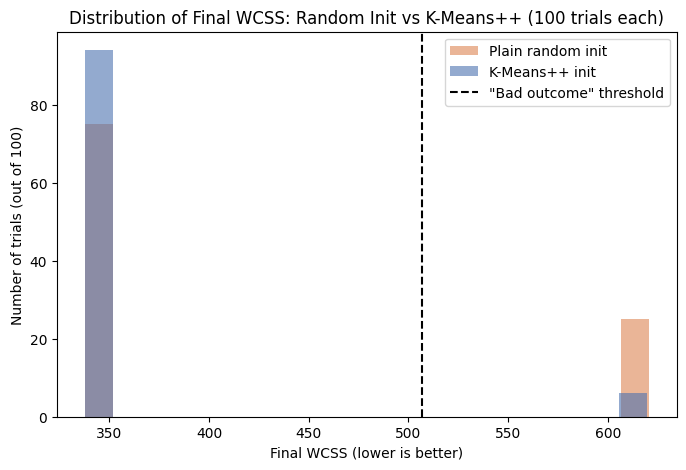

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(random_wcss, bins=20, alpha=0.6, label='Plain random init', color='#DD8452')
plt.hist(pp_wcss, bins=20, alpha=0.6, label='K-Means++ init', color='#4C72B0')
plt.axvline(bad_outcome_threshold, color='black', linestyle='--', linewidth=1.5, label='"Bad outcome" threshold')
plt.xlabel("Final WCSS (lower is better)")
plt.ylabel("Number of trials (out of 100)")
plt.title("Distribution of Final WCSS: Random Init vs K-Means++ (100 trials each)")
plt.legend()
plt.show()

**Observation:**
- Plain random initialization produces a **wide spread of outcomes** — most trials land near the best result, but a meaningful chunk get "unlucky" and land in a clearly worse local optimum (a taller right-hand tail in the histogram).
- K-Means++ initialization produces a **much tighter, more consistent distribution** clustered near the best possible WCSS — it rarely, if ever, lands in a bad outcome.
- This is the rigorous, numbers-based version of the random initialization trap: it's not just a one-off unlucky diagram, it's a **measurable, repeatable pattern** across many runs.

## 5. Why `n_init` Is Extra Insurance (Even With K-Means++)

Scikit-learn's `KMeans` doesn't just rely on K-Means++ alone — by default it also runs the whole
algorithm `n_init` times (default 10 in recent scikit-learn versions) with different K-Means++
initializations, and **automatically keeps the run with the lowest WCSS**. Let's confirm this actually
helps.

n_init= 1 -> mean WCSS: 347.27, worst WCSS: 619.73
n_init= 3 -> mean WCSS: 337.88, worst WCSS: 337.94
n_init= 5 -> mean WCSS: 337.88, worst WCSS: 337.94
n_init=10 -> mean WCSS: 337.88, worst WCSS: 337.94
n_init=20 -> mean WCSS: 337.88, worst WCSS: 337.94


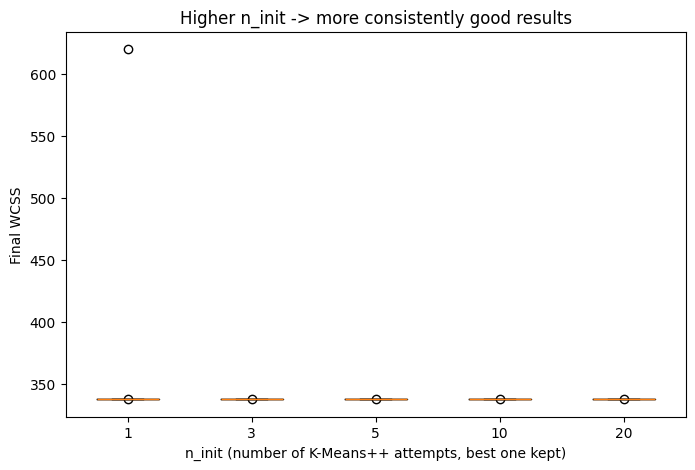

In [6]:
n_init_values = [1, 3, 5, 10, 20]
results = {}

for n_init in n_init_values:
    trial_wcss = []
    for seed in range(30):
        km = KMeans(n_clusters=3, init='k-means++', n_init=n_init, random_state=seed)
        km.fit(X)
        trial_wcss.append(km.inertia_)
    results[n_init] = np.array(trial_wcss)
    print(f"n_init={n_init:>2} -> mean WCSS: {results[n_init].mean():.2f}, worst WCSS: {results[n_init].max():.2f}")

plt.figure(figsize=(8, 5))
plt.boxplot([results[n] for n in n_init_values], tick_labels=[str(n) for n in n_init_values])
plt.xlabel("n_init (number of K-Means++ attempts, best one kept)")
plt.ylabel("Final WCSS")
plt.title("Higher n_init -> more consistently good results")
plt.show()

**Observation:** As `n_init` increases, both the **average** WCSS improves slightly and — more importantly — the **worst-case** WCSS and the spread (box height) shrink. Each additional attempt gives K-Means another chance to avoid an unlucky spread-out initialization, and scikit-learn keeps only the best one. This is why `n_init` and `init='k-means++'` are normally used **together**, not as alternatives to each other.

---
## Final Recap

| Technique | What it does | Effect |
|---|---|---|
| Plain random init (`init='random'`) | Picks K random data points as starting centroids | Can accidentally place 2+ centroids close together -> random initialization trap |
| K-Means++ (`init='k-means++'`, scikit-learn's default) | Spreads out starting centroids deliberately | Drastically reduces bad outcomes, tighter/more consistent WCSS distribution |
| `n_init` (default 10) | Runs the whole algorithm multiple times, keeps the lowest-WCSS result | Extra insurance on top of K-Means++; higher `n_init` = fewer worst-case bad runs |

**Practical takeaway:** In real projects, just use scikit-learn's defaults —
`KMeans(n_clusters=k, init='k-means++', n_init=10)` (or simply `KMeans(n_clusters=k)`, since these
are the defaults in modern scikit-learn) — and you get robust protection against the random
initialization trap without having to think about it. This notebook exists so you've *seen* why that
protection matters, not because you need to configure it manually every time.